In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, log_loss
)

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from torch.utils.data import DataLoader, TensorDataset
import time
from tqdm import tqdm

In [2]:
# Сгенерируем синтетические данные
X, y = make_classification(
    n_samples=1000,  # размер выборки
    n_features=2,  # кол-во признаков для наглядности
    n_classes=2,  # два класса
    n_informative=2,  # кол-во информативных признаков
    n_redundant=0,  # кол-во излишних признаков
    n_repeated=0,  # кол-во повторяющихся признаков
    n_clusters_per_class=1,
    weights=[0.9, 0.1],  # дизбаланс классов, чтобы показать, как его обрабатывать
    flip_y=0.02,  # шум данных: 2% классов определены случайно
    random_state=42  # фиксируем состояние случайности для воспроизводимости
)

In [3]:
# Обучим модели: с дизбалансом и без дизбаланса классов
model_no_balance = LogisticRegression(random_state=42)
model_no_balance.fit(X, y)

# Вес вычисляется обратно пропорционально величине класса
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)
model_balanced.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

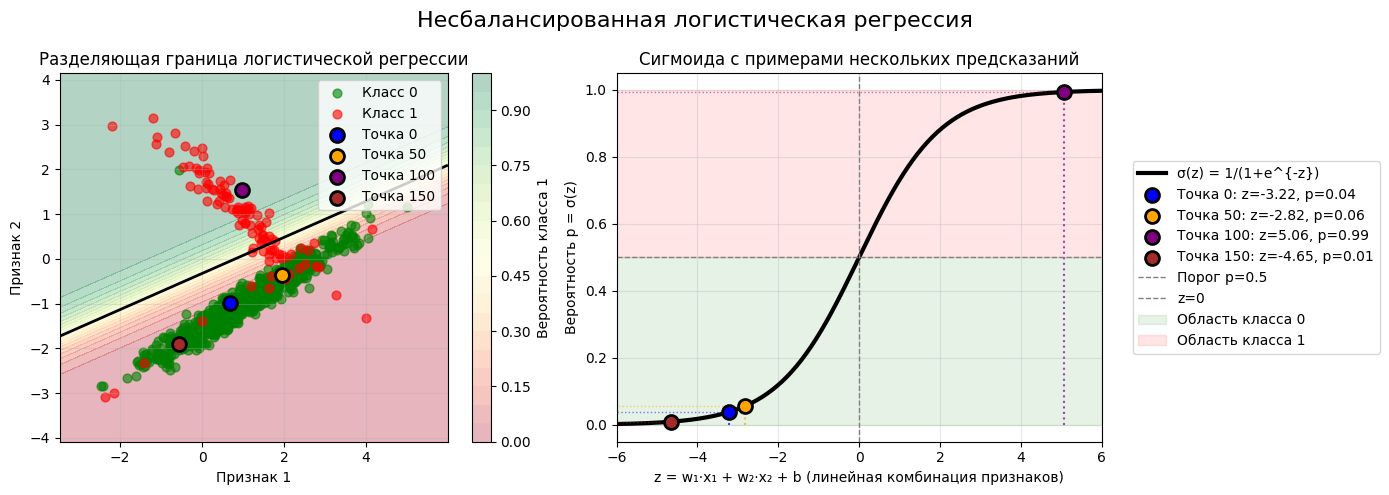

АНАЛИЗ ВЫБРАННЫХ ТОЧЕК:

Коэффициенты модели:
  w1 = -1.3857
  w2 = 3.4314
  b (intercept) = 1.1211

--------------------------------------------------------------------------------

Точка 0 (цвет: blue):
  Признаки: x1 = 0.690, x2 = -0.986
  Расчет z: -1.386*0.690 + 3.431*-0.986 + 1.121 = -3.218
  Сигмоида: p = 1/(1+exp(--3.218)) = 0.038
  Истинный класс: 0 (Нет дефолта)
  Предсказанный: 0 (Нет дефолта)
  Верно/Неверно: ✓

Точка 50 (цвет: orange):
  Признаки: x1 = 1.955, x2 = -0.360
  Расчет z: -1.386*1.955 + 3.431*-0.360 + 1.121 = -2.821
  Сигмоида: p = 1/(1+exp(--2.821)) = 0.056
  Истинный класс: 0 (Нет дефолта)
  Предсказанный: 0 (Нет дефолта)
  Верно/Неверно: ✓

Точка 100 (цвет: purple):
  Признаки: x1 = 0.962, x2 = 1.538
  Расчет z: -1.386*0.962 + 3.431*1.538 + 1.121 = 5.064
  Сигмоида: p = 1/(1+exp(-5.064)) = 0.994
  Истинный класс: 1 (Дефолт)
  Предсказанный: 1 (Дефолт)
  Верно/Неверно: ✓

Точка 150 (цвет: brown):
  Признаки: x1 = -0.561, x2 = -1.908
  Расчет z: -1.386*-0.561 +

In [10]:
# Построим графики и покажем, как логистическая регрессия строит гиперплоскость
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Линейная комбинация и преобразование
z_values = np.dot(X, model_no_balance.coef_.T) + model_no_balance.intercept_
sigmoid_predictions_no_balance = sigmoid(z_values)

# Визуализации
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Несбалансированная логистическая регрессия', fontsize=16)

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100)
)
Z = model_no_balance.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)
contour = ax1.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn', levels=20)
plt.colorbar(contour, ax=ax1, label='Вероятность класса 1')
ax1.scatter(X[y==0, 0], X[y==0, 1], color='green', alpha=0.6, label='Класс 0', s=40)
ax1.scatter(X[y==1, 0], X[y==1, 1], color='red', alpha=0.6, label='Класс 1', s=40)

# Границы вероятности p=0.5
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

# Точки для демонстрации
selected_indices = [0, 50, 100, 150]
colors = ['blue', 'orange', 'purple', 'brown']

for idx, color in zip(selected_indices, colors):
    ax1.scatter(X[idx, 0], X[idx, 1], color=color, s=100, edgecolor='black',
                linewidth=2, label=f'Точка {idx}', zorder=10)

ax1.set_xlabel('Признак 1')
ax1.set_ylabel('Признак 2')
ax1.set_title('Разделяющая граница логистической регрессии')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

z_range = np.linspace(-8, 8, 400)
sigmoid_curve = sigmoid(z_range)

ax2.plot(z_range, sigmoid_curve, 'k-', linewidth=3, label='σ(z) = 1/(1+e^{-z})')

for idx, color in zip(selected_indices, colors):
    z_val = z_values[idx][0]
    p_val = sigmoid_predictions_no_balance[idx][0]

    ax2.plot([z_val, z_val], [0, p_val], color=color, linestyle=':', alpha=0.7, linewidth=1.5)

    ax2.plot([z_val, -8], [p_val, p_val], color=color, linestyle=':', alpha=0.5, linewidth=1)

    ax2.scatter(z_val, p_val, color=color, s=100, edgecolor='black',
                linewidth=2, label=f'Точка {idx}: z={z_val:.2f}, p={p_val:.2f}', zorder=10)

ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Порог p=0.5')
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='z=0')

ax2.fill_between(z_range, 0, 0.5, alpha=0.1, color='green', label='Область класса 0')
ax2.fill_between(z_range, 0.5, 1, alpha=0.1, color='red', label='Область класса 1')

ax2.set_xlabel('z = w₁·x₁ + w₂·x₂ + b (линейная комбинация признаков)')
ax2.set_ylabel('Вероятность p = σ(z)')
ax2.set_title('Сигмоида с примерами нескольких предсказаний')
ax2.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('Z:\diplom\diplom\images\chapter1\\no_balanced_log_func.png')
plt.show()

print("=" * 80)
print("АНАЛИЗ ВЫБРАННЫХ ТОЧЕК:")
print("=" * 80)
print("\nКоэффициенты модели:")
print(f"  w1 = {model_no_balance.coef_[0][0]:.4f}")
print(f"  w2 = {model_no_balance.coef_[0][1]:.4f}")
print(f"  b (intercept) = {model_no_balance.intercept_[0]:.4f}")
print("\n" + "-" * 80)

for idx, color in zip(selected_indices, colors):
    x1, x2 = X[idx]
    z = z_values[idx][0]
    p = sigmoid_predictions_no_balance[idx][0]
    true_class = y[idx]
    pred_class = 1 if p > 0.5 else 0

    print(f"\nТочка {idx} (цвет: {color}):")
    print(f"  Признаки: x1 = {x1:.3f}, x2 = {x2:.3f}")
    print(f"  Расчет z: {model_no_balance.coef_[0][0]:.3f}*{x1:.3f} + {model_no_balance.coef_[0][1]:.3f}*{x2:.3f} + {model_no_balance.intercept_[0]:.3f} = {z:.3f}")
    print(f"  Сигмоида: p = 1/(1+exp(-{z:.3f})) = {p:.3f}")
    print(f"  Истинный класс: {true_class} ({'Дефолт' if true_class == 1 else 'Нет дефолта'})")
    print(f"  Предсказанный: {pred_class} ({'Дефолт' if pred_class == 1 else 'Нет дефолта'})")
    print(f"  Верно/Неверно: {'✓' if true_class == pred_class else '✗'}")
print(classification_report(y, model_no_balance.predict(X)))

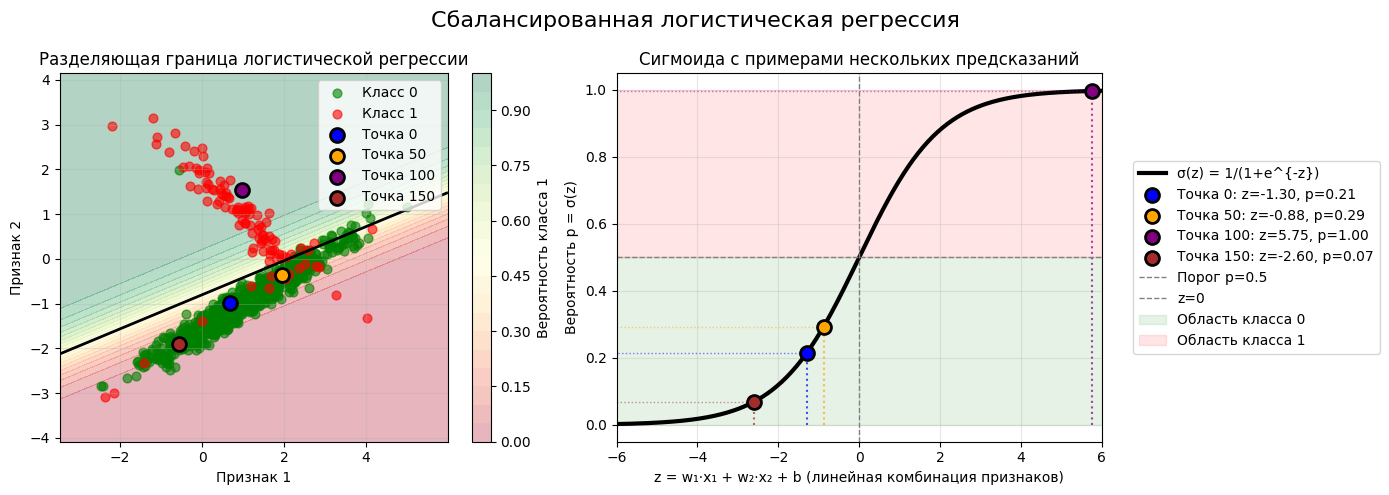

АНАЛИЗ ВЫБРАННЫХ ТОЧЕК:

Коэффициенты модели:
  w1 = -1.3857
  w2 = 3.4314
  b (intercept) = 1.1211

--------------------------------------------------------------------------------

Точка 0 (цвет: blue):
  Признаки: x1 = 0.690, x2 = -0.986
  Расчет z: -1.386*0.690 + 3.431*-0.986 + 1.121 = -1.299
  Сигмоида: p = 1/(1+exp(--1.299)) = 0.214
  Истинный класс: 0 (Нет дефолта)
  Предсказанный: 0 (Нет дефолта)
  Верно/Неверно: ✓

Точка 50 (цвет: orange):
  Признаки: x1 = 1.955, x2 = -0.360
  Расчет z: -1.386*1.955 + 3.431*-0.360 + 1.121 = -0.878
  Сигмоида: p = 1/(1+exp(--0.878)) = 0.293
  Истинный класс: 0 (Нет дефолта)
  Предсказанный: 0 (Нет дефолта)
  Верно/Неверно: ✓

Точка 100 (цвет: purple):
  Признаки: x1 = 0.962, x2 = 1.538
  Расчет z: -1.386*0.962 + 3.431*1.538 + 1.121 = 5.748
  Сигмоида: p = 1/(1+exp(-5.748)) = 0.997
  Истинный класс: 1 (Дефолт)
  Предсказанный: 1 (Дефолт)
  Верно/Неверно: ✓

Точка 150 (цвет: brown):
  Признаки: x1 = -0.561, x2 = -1.908
  Расчет z: -1.386*-0.561 +

In [11]:
# Линейная комбинация и преобразование
z_values = np.dot(X, model_balanced.coef_.T) + model_balanced.intercept_
sigmoid_predictions_balanced = sigmoid(z_values)

# Визуализации
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сбалансированная логистическая регрессия', fontsize=16)

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100)
)
Z = model_balanced.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)
contour = ax1.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn', levels=20)
plt.colorbar(contour, ax=ax1, label='Вероятность класса 1')
ax1.scatter(X[y==0, 0], X[y==0, 1], color='green', alpha=0.6, label='Класс 0', s=40)
ax1.scatter(X[y==1, 0], X[y==1, 1], color='red', alpha=0.6, label='Класс 1', s=40)

# Границы вероятности p=0.5
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

# Точки для демонстрации
selected_indices = [0, 50, 100, 150]
colors = ['blue', 'orange', 'purple', 'brown']

for idx, color in zip(selected_indices, colors):
    ax1.scatter(X[idx, 0], X[idx, 1], color=color, s=100, edgecolor='black',
                linewidth=2, label=f'Точка {idx}', zorder=10)

ax1.set_xlabel('Признак 1')
ax1.set_ylabel('Признак 2')
ax1.set_title('Разделяющая граница логистической регрессии')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

z_range = np.linspace(-8, 8, 400)
sigmoid_curve = sigmoid(z_range)

ax2.plot(z_range, sigmoid_curve, 'k-', linewidth=3, label='σ(z) = 1/(1+e^{-z})')

for idx, color in zip(selected_indices, colors):
    z_val = z_values[idx][0]
    p_val = sigmoid_predictions_balanced[idx][0]

    ax2.plot([z_val, z_val], [0, p_val], color=color, linestyle=':', alpha=0.7, linewidth=1.5)

    ax2.plot([z_val, -8], [p_val, p_val], color=color, linestyle=':', alpha=0.5, linewidth=1)

    ax2.scatter(z_val, p_val, color=color, s=100, edgecolor='black',
                linewidth=2, label=f'Точка {idx}: z={z_val:.2f}, p={p_val:.2f}', zorder=10)

ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Порог p=0.5')
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='z=0')

ax2.fill_between(z_range, 0, 0.5, alpha=0.1, color='green', label='Область класса 0')
ax2.fill_between(z_range, 0.5, 1, alpha=0.1, color='red', label='Область класса 1')

ax2.set_xlabel('z = w₁·x₁ + w₂·x₂ + b (линейная комбинация признаков)')
ax2.set_ylabel('Вероятность p = σ(z)')
ax2.set_title('Сигмоида с примерами нескольких предсказаний')
ax2.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('Z:\diplom\diplom\images\chapter1\\balanced_log_func.png')
plt.show()

print("=" * 80)
print("АНАЛИЗ ВЫБРАННЫХ ТОЧЕК:")
print("=" * 80)
print("\nКоэффициенты модели:")
print(f"  w1 = {model_no_balance.coef_[0][0]:.4f}")
print(f"  w2 = {model_no_balance.coef_[0][1]:.4f}")
print(f"  b (intercept) = {model_no_balance.intercept_[0]:.4f}")
print("\n" + "-" * 80)

for idx, color in zip(selected_indices, colors):
    x1, x2 = X[idx]
    z = z_values[idx][0]
    p = sigmoid_predictions_balanced[idx][0]
    true_class = y[idx]
    pred_class = 1 if p > 0.5 else 0

    print(f"\nТочка {idx} (цвет: {color}):")
    print(f"  Признаки: x1 = {x1:.3f}, x2 = {x2:.3f}")
    print(f"  Расчет z: {model_no_balance.coef_[0][0]:.3f}*{x1:.3f} + {model_no_balance.coef_[0][1]:.3f}*{x2:.3f} + {model_no_balance.intercept_[0]:.3f} = {z:.3f}")
    print(f"  Сигмоида: p = 1/(1+exp(-{z:.3f})) = {p:.3f}")
    print(f"  Истинный класс: {true_class} ({'Дефолт' if true_class == 1 else 'Нет дефолта'})")
    print(f"  Предсказанный: {pred_class} ({'Дефолт' if pred_class == 1 else 'Нет дефолта'})")
    print(f"  Верно/Неверно: {'✓' if true_class == pred_class else '✗'}")
print(classification_report(y, model_balanced.predict(X)))

In [13]:
print(np.round(log_loss(y, model_no_balance.predict(X)), 2), np.round(log_loss(y, model_balanced.predict(X)), 2))

1.19 1.37


In [14]:
X, y = make_classification(
    n_samples=5000,
    n_features=10,  # больше признаков для демонстрации более сложных связей
    n_informative=6,
    n_redundant=2,
    n_clusters_per_class=2,  # нелинейность
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0.05,
    random_state=42
)
print(f"Размер датасета: {X.shape}")
print(f"Распределение классов: {np.bincount(y)}")
print(f"Доля класса 1 (дефолт): {np.mean(y):.2%}")

Размер датасета: (5000, 10)
Распределение классов: [4160  840]
Доля класса 1 (дефолт): 16.80%


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

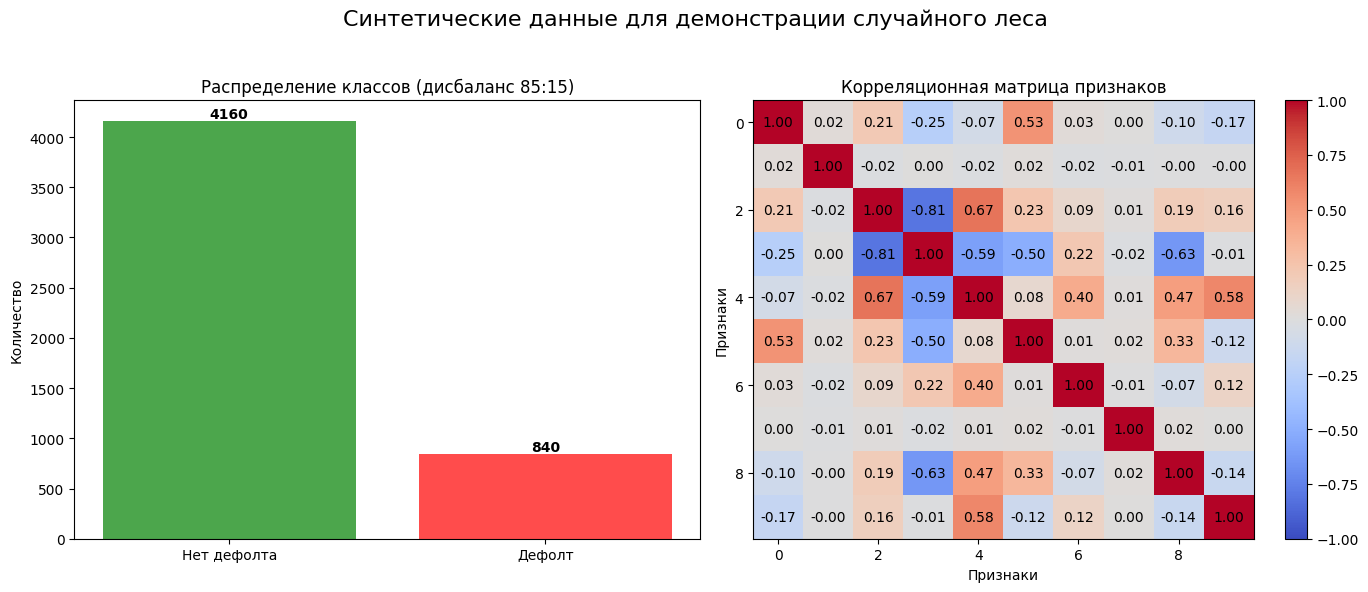

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Синтетические данные для демонстрации случайного леса', fontsize=16)

# 2.1. Распределение классов
axes[0].bar(['Нет дефолта', 'Дефолт'], np.bincount(y), color=['green', 'red'], alpha=0.7)
axes[0].set_title('Распределение классов (дисбаланс 85:15)')
axes[0].set_ylabel('Количество')
axes[0].text(0, np.bincount(y)[0], f'{np.bincount(y)[0]}', ha='center', va='bottom', fontweight='bold')
axes[0].text(1, np.bincount(y)[1], f'{np.bincount(y)[1]}', ha='center', va='bottom', fontweight='bold')

# 2.2. Корреляционная матрица признаков
corr_matrix = np.corrcoef(X.T)
im = axes[1].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1].set_title('Корреляционная матрица признаков')
axes[1].set_xlabel('Признаки')
axes[1].set_ylabel('Признаки')
plt.colorbar(im, ax=axes[1])

# Добавляем аннотации вручную
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        axes[1].text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', color='black')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # чтоб suptitle не накладывался
plt.savefig('Z:\diplom\diplom\images\chapter1\corr_and_distr.png')
plt.show()


In [17]:
models = {
    'Без балансировки': RandomForestClassifier(
        n_estimators=100,  # кол-во деревьев в лесу
        max_depth=10,  # максимальная глубина дерева
        random_state=42,
        n_jobs=-1  # ускоренная тренировка модели за счёт использования всех ядер
    ),
    'С балансировкой (class_weight)': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',  # то же самое, что и в логистической регрессии
        random_state=42,
        n_jobs=-1
    ),
    'С балансировкой (balanced_subsample)': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced_subsample',  # принцип работы тот же, что и у 'balanced' за исключением того, что вес расчитывается на основе бутстрапированных выборок для каждого дерева
        random_state=42,
        n_jobs=-1
    ),
    'С увеличенным весом редкого класса': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight={0: 1, 1: 3},  # утяжеление редкого класса большим весом
        random_state=42,
        n_jobs=-1
    )
}

# Обучение и предсказание
results = {}
for name, model in models.items():
    print(f"\nОбучение модели: {name}")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Собираем результаты
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'feature_importance': model.feature_importances_
    }

    print(classification_report(y_test, y_pred,
                                target_names=['Нет дефолта', 'Дефолт']))
    print(f'\nКросс-энтропия: {np.round(log_loss(y_test, y_pred), 2)}')


Обучение модели: Без балансировки
              precision    recall  f1-score   support

 Нет дефолта       0.90      0.99      0.94      1248
      Дефолт       0.88      0.48      0.62       252

    accuracy                           0.90      1500
   macro avg       0.89      0.73      0.78      1500
weighted avg       0.90      0.90      0.89      1500


Кросс-энтропия: 3.56

Обучение модели: С балансировкой (class_weight)
              precision    recall  f1-score   support

 Нет дефолта       0.92      0.96      0.94      1248
      Дефолт       0.74      0.61      0.67       252

    accuracy                           0.90      1500
   macro avg       0.83      0.78      0.81      1500
weighted avg       0.89      0.90      0.90      1500


Кросс-энтропия: 3.63

Обучение модели: С балансировкой (balanced_subsample)
              precision    recall  f1-score   support

 Нет дефолта       0.92      0.96      0.94      1248
      Дефолт       0.76      0.59      0.66       252


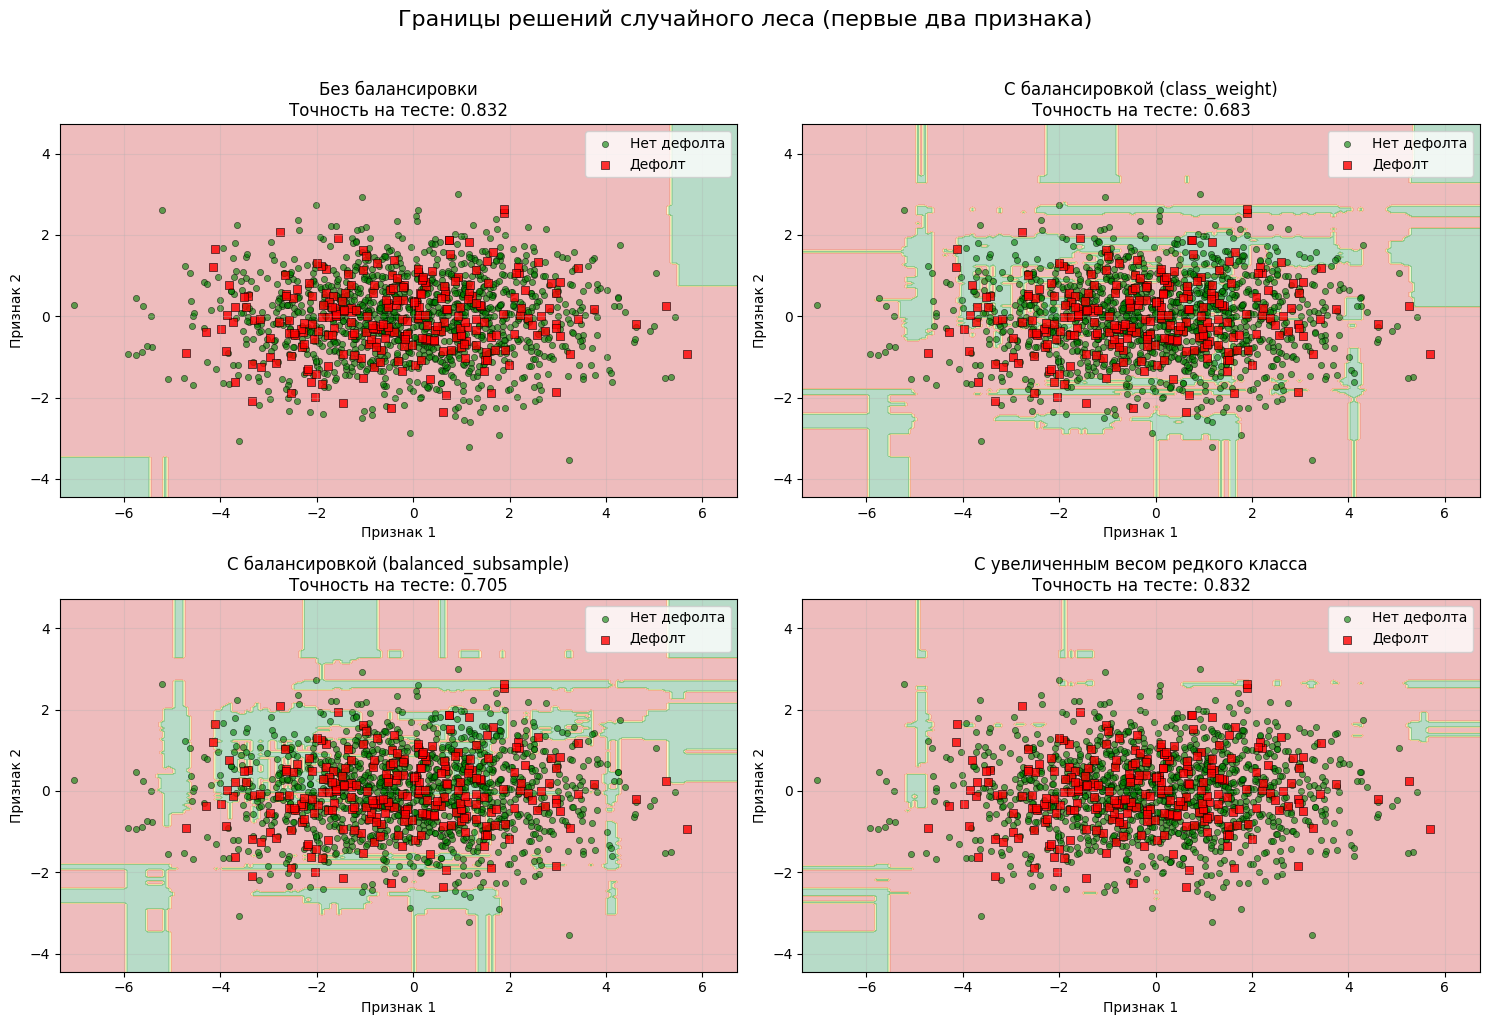

In [19]:
# Берем только первые два признака для визуализации
X_vis = X_train[:, :2]
X_test_vis = X_test[:, :2]

# Обучаем модели на двух признаках для визуализации
models_vis = {}
for name in models.keys():
    models_vis[name] = RandomForestClassifier(
        n_estimators=50,  # Меньше деревьев для скорости
        max_depth=5,
        class_weight=models[name].class_weight,
        random_state=42
    )
    models_vis[name].fit(X_vis, y_train)

# Создаем сетку для построения границ
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Границы решений случайного леса (первые два признака)',
             fontsize=16, y=1.02)

for idx, (name, model) in enumerate(models_vis.items()):
    ax = axes[idx // 2, idx % 2]

    # Предсказания для сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Контур границы
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')

    # Точки данных (только тестовые для чистоты)
    scatter0 = ax.scatter(X_test_vis[y_test==0, 0], X_test_vis[y_test==0, 1],
                         c='green', alpha=0.6, s=20, label='Нет дефолта',
                         edgecolors='k', linewidth=0.5)
    scatter1 = ax.scatter(X_test_vis[y_test==1, 0], X_test_vis[y_test==1, 1],
                         c='red', alpha=0.8, s=40, label='Дефолт',
                         edgecolors='k', linewidth=0.5, marker='s')

    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')
    ax.set_title(f'{name}\nТочность на тесте: {model.score(X_test_vis, y_test):.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Z:\diplom\diplom\images\chapter1\\rf_decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Возьмём датасет, с помощью которого лего визуализировать алгоритмы классификации
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)

# Разделим на выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Баланс классов: {np.bincount(y_train)}")

Размер тренировочной выборки: (700, 2)
Размер тестовой выборки: (300, 2)
Баланс классов: [344 356]


In [21]:
# Создадим алгоритм и зададим параметры
model = GradientBoostingClassifier(
    n_estimators=100,      # Количество деревьев
    learning_rate=0.1,     # Скорость обучения - чтобы избежать overfitting
    max_depth=3,           # Максимальная глубина каждого дерева
    random_state=42
)

In [22]:
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [23]:
# Запустим предсказания
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Вероятности для ROC-AUC

In [24]:
# Метрики
print("\n" + "="*50)
print("МЕТРИКИ КАЧЕСТВА:")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy (Точность): {accuracy:.4f}")
print(f"Precision (Точность): {precision:.4f}")
print(f"Recall (Полнота): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


МЕТРИКИ КАЧЕСТВА:
Accuracy (Точность): 0.9233
Precision (Точность): 0.9231
Recall (Полнота): 0.9167
F1-Score: 0.9199
ROC-AUC: 0.9773


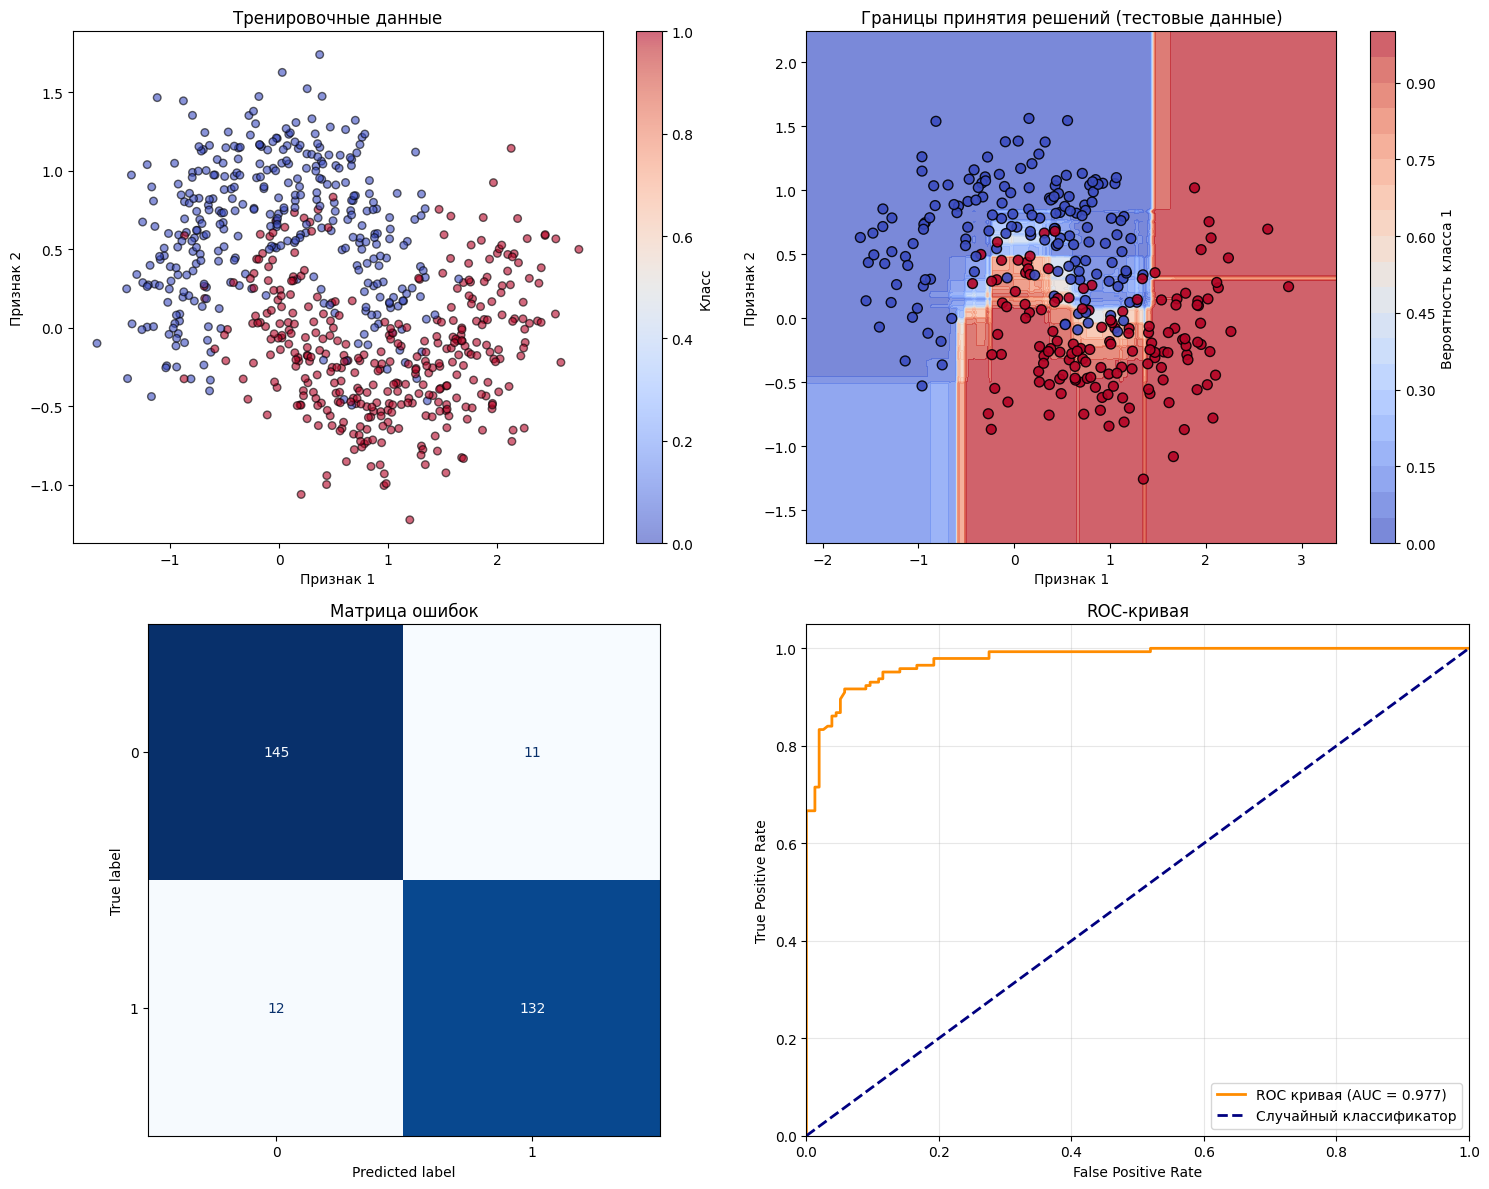

In [25]:
# Визуализируем данные
fig, axes = plt.subplots(2, 2, figsize=(15, 12))


# Исходные
ax = axes[0, 0]
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm',
                     alpha=0.6, edgecolors='k', s=30)
ax.set_title("Тренировочные данные")
ax.set_xlabel("Признак 1")
ax.set_ylabel("Признак 2")
plt.colorbar(scatter, ax=ax, label='Класс')

# Граница решений
ax = axes[0, 1]

# Создаем сетку для предсказаний
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200)
)

# Предсказания для каждой точки сетки
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Контурный график с границами решений
contour = ax.contourf(xx, yy, Z, alpha=0.7, cmap='coolwarm', levels=20)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm',
           edgecolors='k', s=50, alpha=0.9)
ax.set_title("Границы принятия решений (тестовые данные)")
ax.set_xlabel("Признак 1")
ax.set_ylabel("Признак 2")
plt.colorbar(contour, ax=ax, label='Вероятность класса 1')

# Матрица ошибок
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Матрица ошибок")

# ROC-AUC
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC кривая (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Z:\diplom\diplom\images\chapter1\\boosting_viz.png')
plt.show()

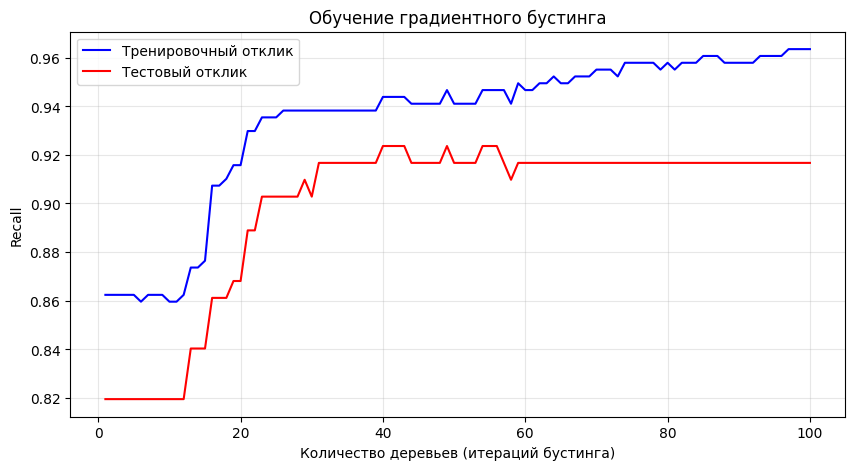

In [26]:
train_errors = []
test_errors = []

for i, y_pred_stage in enumerate(model.staged_predict(X_test)):
    train_errors.append(recall_score(y_train, list(model.staged_predict(X_train))[i]))
    test_errors.append(recall_score(y_test, y_pred_stage))

# График обучения
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_errors) + 1), train_errors, 'b-', label='Тренировочный отклик')
ax.plot(range(1, len(test_errors) + 1), test_errors, 'r-', label='Тестовый отклик')
ax.set_xlabel('Количество деревьев (итераций бустинга)')
ax.set_ylabel('Recall')
ax.set_title('Обучение градиентного бустинга')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('Z:\diplom\diplom\images\chapter1\\boosting_learning.png')
plt.show()

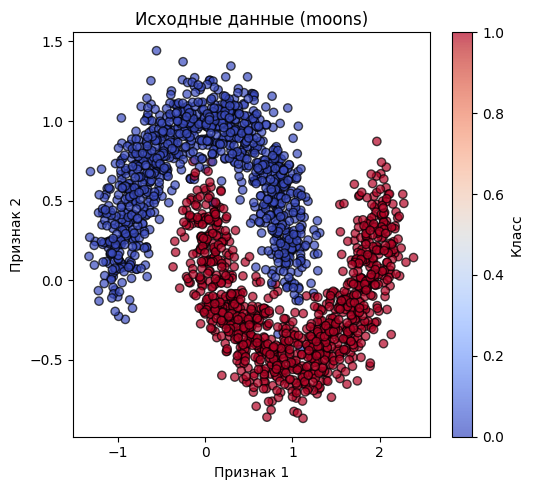

In [27]:
def generate_data(n_samples=1000, dataset_type='moons', noise=0.1):
    """Генерация синтетических данных для бинарной классификации"""
    if dataset_type == 'moons':
        X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)
    elif dataset_type == 'circles':
        X, y = make_circles(n_samples=n_samples, noise=noise, random_state=42, factor=0.5)
    else:
        # Линейно разделимые данные
        X = np.random.randn(n_samples, 2)
        y = (X[:, 0] + X[:, 1] > 0).astype(int)

    return X, y

# Параметры
N_SAMPLES = 2000
DATASET_TYPE = 'moons'  # 'moons', 'circles', или 'linear'
NOISE = 0.15

# Генерация данных
X, y = generate_data(N_SAMPLES, DATASET_TYPE, NOISE)

# Визуализация исходных данных
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title(f'Исходные данные ({DATASET_TYPE})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Класс')
plt.tight_layout()
plt.savefig('Z:\diplom\diplom\images\chapter1\moons.png')
plt.show()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Преобразование в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# Создание DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 1400
Размер тестовой выборки: 600


In [29]:
class MLPBinaryClassifier(nn.Module):
    """Многослойный перцептрон для бинарной классификации"""
    def __init__(self, input_dim=2, hidden_dims=[64, 32, 16], dropout_rate=0.2):
        super(MLPBinaryClassifier, self).__init__()

        layers = []
        prev_dim = input_dim

        # Динамическое создание скрытых слоев
        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        # Выходной слой
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

model = MLPBinaryClassifier(
    input_dim=2,
    hidden_dims=[128, 64, 32],
    dropout_rate=0.3
).to(device)

# Функция потерь и оптимизатор
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)

print(model)
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

Используемое устройство: cpu
MLPBinaryClassifier(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)
Количество параметров: 11,201


In [31]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Обучение на одной эпохе"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Статистика
        total_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    """Оценка модели"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()

            predicted = (outputs > 0.5).float()
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    return total_loss / len(loader), np.array(all_predictions), np.array(all_targets)

# Обучение
n_epochs = 100
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
patience_counter = 0
patience = 20

print("\nНачало обучения...")
start_time = time.time()

for epoch in tqdm(range(n_epochs), desc="Эпохи"):
    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Валидация
    val_loss, val_preds, val_targets = evaluate(model, test_loader, criterion, device)
    val_acc = accuracy_score(val_targets, val_preds > 0.5)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Планировщик скорости обучения
    scheduler.step(val_loss)

    # Ранняя остановка
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Сохранение лучшей модели
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nРанняя остановка на эпохе {epoch+1}")
        break

    if epoch % 20 == 0:
        print(f"\nЭпоха {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

training_time = time.time() - start_time
print(f"\nОбучение завершено за {training_time:.2f} секунд")

# Загрузка лучшей модели
model.load_state_dict(torch.load('best_model.pth'))


Начало обучения...


Эпохи:   1%|          | 1/100 [00:00<00:15,  6.52it/s]


Эпоха 1: Train Loss: 0.4341, Train Acc: 0.8279, Val Loss: 0.2825, Val Acc: 0.9233


Эпохи:  23%|██▎       | 23/100 [00:02<00:05, 12.93it/s]


Эпоха 21: Train Loss: 0.0962, Train Acc: 0.9686, Val Loss: 0.0328, Val Acc: 0.9900


Эпохи:  43%|████▎     | 43/100 [00:03<00:04, 13.52it/s]


Эпоха 41: Train Loss: 0.0806, Train Acc: 0.9736, Val Loss: 0.0370, Val Acc: 0.9867


Эпохи:  63%|██████▎   | 63/100 [00:04<00:02, 13.61it/s]


Эпоха 61: Train Loss: 0.0707, Train Acc: 0.9750, Val Loss: 0.0296, Val Acc: 0.9917


Эпохи:  73%|███████▎  | 73/100 [00:05<00:02, 12.50it/s]


Ранняя остановка на эпохе 74

Обучение завершено за 5.85 секунд


<All keys matched successfully>

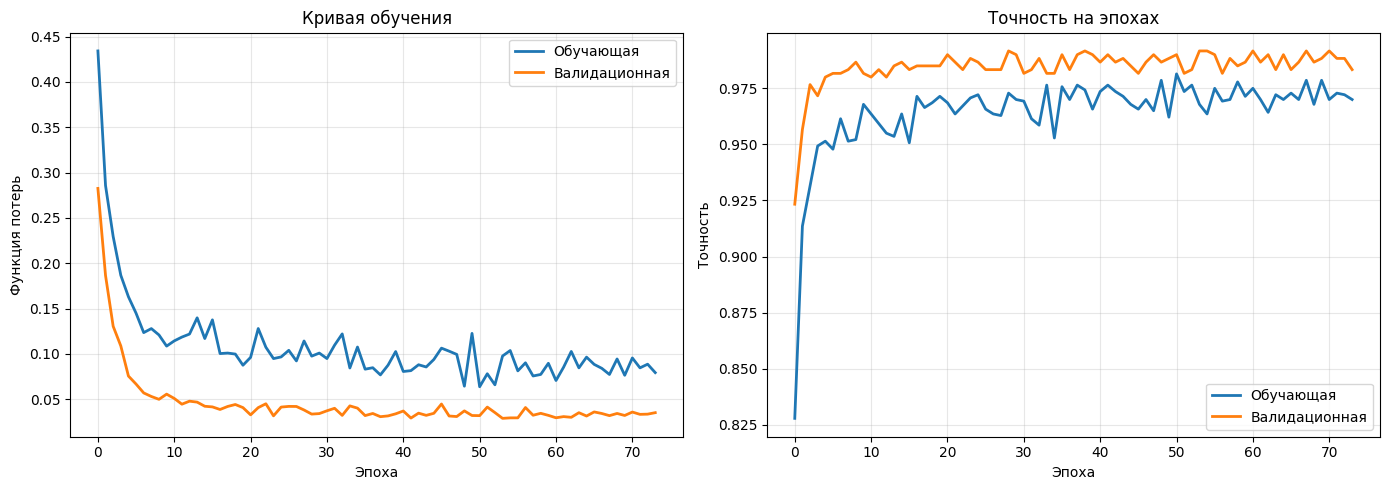

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График функции потерь
axes[0].plot(train_losses, label='Обучающая', linewidth=2)
axes[0].plot(val_losses, label='Валидационная', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Функция потерь')
axes[0].set_title('Кривая обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График точности
axes[1].plot(train_accuracies, label='Обучающая', linewidth=2)
axes[1].plot(val_accuracies, label='Валидационная', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность')
axes[1].set_title('Точность на эпохах')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Z:\diplom\diplom\images\chapter1\\neural_net_learning.png')
plt.show()


МЕТРИКИ КЛАССИФИКАЦИИ:
Точность (Accuracy):  0.9917
Прецизионность (Precision): 0.9868
Полнота (Recall):     0.9967
F1-мера:              0.9917


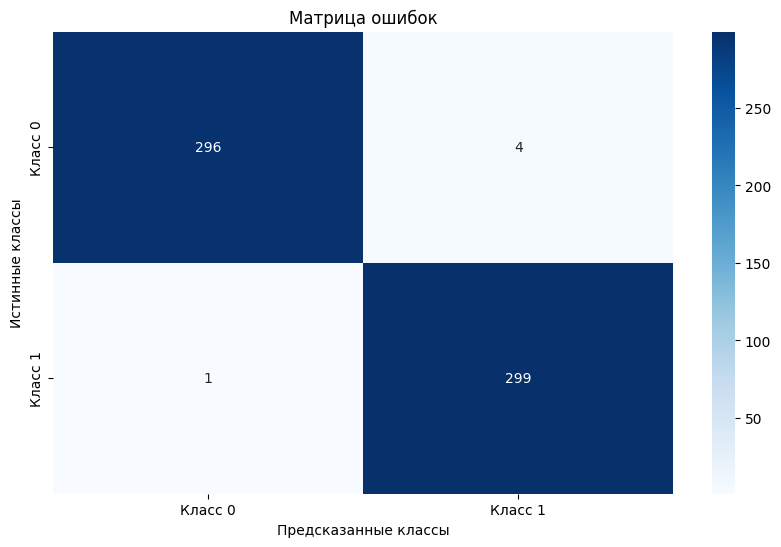

In [33]:
model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_pred_proba = model(X_test_tensor).cpu().numpy()
    y_pred = (y_pred_proba > 0.5).astype(int)

# Метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*50)
print("МЕТРИКИ КЛАССИФИКАЦИИ:")
print("="*50)
print(f"Точность (Accuracy):  {accuracy:.4f}")
print(f"Прецизионность (Precision): {precision:.4f}")
print(f"Полнота (Recall):     {recall:.4f}")
print(f"F1-мера:              {f1:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Класс 0', 'Класс 1'],
            yticklabels=['Класс 0', 'Класс 1'])
plt.title('Матрица ошибок')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.savefig('Z:\diplom\diplom\images\chapter1\conf_matrix.png')
plt.show()

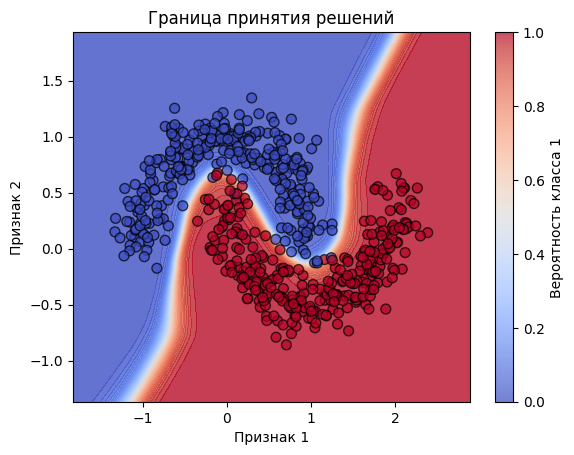

In [34]:
# Создание сетки для визуализации
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Предсказание для каждой точки сетки
with torch.no_grad():
    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    Z = model(grid_tensor).cpu().numpy()
    Z = Z.reshape(xx.shape)

# Визуализация границы решения
plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.8)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
            cmap='coolwarm', edgecolors='k', s=50, alpha=0.7)
plt.title('Граница принятия решений')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Вероятность класса 1')
plt.savefig('Z:\diplom\diplom\images\chapter1\decision_bound_nn.png')
plt.show()